# Clustering Methods Comparison Plots

This notebook generates comparison plots for 9 clustering methods:
- HDBSCAN
- Graph Clustering (GC)
- Manual Review
- Thresholded Review
- **Stability (LCA v3)** - New stability-driven clustering algorithm
- **NP3+AAS** - Non-Parametric Plug-and-Play with Ambiguity-Aware Sampling
- **NIS** - Nested Importance Sampling + k-means (population size estimation)
- **GT Top-K** - Ground Truth Top-K Graph (upper-bound reference: K nearest neighbors + GT labeling)
- **JEIG** - Joint Expected Information Gain active querying

Metrics plotted:
- F1 Score vs Number of Human Reviews
- Precision vs Number of Human Reviews
- Recall vs Number of Human Reviews
- **Cluster Count Ratio vs Number of Human Reviews** (predicted clusters / true clusters, 1.0 = perfect)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import pickle
import os
from pathlib import Path
import warnings
import re
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

# Define colors for each method
METHOD_COLORS = {
    'HDBSCAN': '#1f77b4',
    'GC': '#ff7f0e',
    'Manual Review': '#2ca02c',
    'Thresholded Review': '#d62728',
    'Stability': '#9467bd',
    'NP3+AAS': '#8c564b',
    'NIS': '#17becf',
    'GT Top-K': '#e377c2',
    'JEIG (Clipped)': '#bcbd22',      # Olive green for old clipped run
    'JEIG (Full-Range)': '#d62728'    # Red for the new unclipped run
}

In [2]:
# ==========================================
# Configuration - UPDATE THESE SETTINGS
# ==========================================
SPECIES = 'GZCD'  # e.g., 'whaleshark', 'beluga', 'forestelephants'
name_field = 'name'

BASE_PATH = Path('/fs/ess/PAS2136/ggr_data/results/aidan')
TMP_PATH = Path('/users/PAS2136/westpa/lca_out')
PLOT_PATH = BASE_PATH / SPECIES / 'plots' 
PLOT_PATH.mkdir(parents=True, exist_ok=True)

# Maximum number of human reviews to include in plots
max_human_reviews = 5000

# ==========================================
# Direct Log File Paths
# ==========================================
LOG_PATHS = {
    #'HDBSCAN': TMP_PATH / SPECIES / 'output' / 'hdbscan_output.log',
    #'Manual Review': TMP_PATH / SPECIES / 'output' / 'manual_review_output.log',
    #'Thresholded Review': TMP_PATH / SPECIES / 'output' / 'thresholded_review_output.log',
    'Stability': TMP_PATH / SPECIES / 'output' / 'stability_output.log',
    #'NP3+AAS': TMP_PATH / SPECIES / 'output' / 'np3_aas_output.log',
    #'NIS': TMP_PATH / SPECIES / 'output' / 'nis_reference_sweep.log',
    #'GT Top-K': TMP_PATH / SPECIES / 'output' / 'gt_topk.log',
    
    # Original JEIG run with clipped thresholding
    'JEIG (Clipped)': TMP_PATH / SPECIES/ 'stability_universal_output.log',
    
    # New JEIG run using the full-range score mapping
    'JEIG (Full-Range)': TMP_PATH / SPECIES/ 'stability_universal_output_2.log'
}

print(f"Analyzing dataset: {SPECIES}")
print(f"Max human reviews: {max_human_reviews}\n")
print("Checking for log files:")
for method, path in LOG_PATHS.items():
    exists = path.exists() if path else False
    print(f"{method}: {'✓' if exists else '✗'} {path}")

Analyzing dataset: GZCD
Max human reviews: 5000

Checking for log files:
Stability: ✓ /users/PAS2136/westpa/lca_out/GZCD/output/stability_output.log
JEIG (Clipped): ✓ /users/PAS2136/westpa/lca_out/GZCD/stability_universal_output.log
JEIG (Full-Range): ✓ /users/PAS2136/westpa/lca_out/GZCD/stability_universal_output_2.log


In [3]:
# Configuration for metric type: 'classic' (pairwise) or 'hungarian' (cluster-level)
METRIC_TYPE = 'hungarian' 

def _extract_mean(s):
    """Extract mean value from 'mean±std' or plain float string."""
    s = s.strip()
    if '±' in s:
        return float(s.split('±')[0])
    try:
        return float(s)
    except ValueError:
        return None

def parse_log_file(filepath, method, metric_type='classic'):
    if not filepath.exists():
        print(f"Warning: Log file not found: {filepath}")
        return None
    
    with open(filepath, 'r') as f:
        content = f.read()
    
    metrics_data = []
    
    gt_clusters_header = re.search(r'number of individuals:\s*(\d+)', content)
    num_gt_from_header = int(gt_clusters_header.group(1)) if gt_clusters_header else None
    
    if metric_type == 'hungarian':
        f1_pattern = r'Hungarian F1 Score:\s+([\d.]+)'
        precision_pattern = r'Hungarian Precision:\s+([\d.]+)'
        recall_pattern = r'Hungarian Recall:\s+([\d.]+)'
        json_f1_key = r'"Hungarian f1 score":\s*([\d.]+)'
        json_precision_key = r'"Hungarian precision":\s*([\d.]+)'
        json_recall_key = r'"Hungarian recall":\s*([\d.]+)'
    else:
        f1_pattern = r'(?<!Hungarian )F1 Score:\s+([\d.]+)'
        precision_pattern = r'(?<!Hungarian )Precision:\s+([\d.]+)'
        recall_pattern = r'(?<!Hungarian )Recall:\s+([\d.]+)'
        json_f1_key = r'"f1 score":\s*([\d.]+)'
        json_precision_key = r'"precision":\s*([\d.]+)'
        json_recall_key = r'"recall":\s*([\d.]+)'
    
    if method == 'HDBSCAN':
        f1_match = re.search(f1_pattern, content)
        precision_match = re.search(precision_pattern, content)
        recall_match = re.search(recall_pattern, content)
        fraccorrect_match = re.search(r'Fraction Correct:\s+([\d.]+)', content)
        num_pred_match = re.search(r'Number of clusters:\s*(\d+)', content)
        num_gt_match = re.search(r'Number of true clusters:\s*(\d+)', content)
        
        if not num_pred_match: num_pred_match = re.search(r'"Number of clusters":\s*(\d+)', content)
        if not num_gt_match: num_gt_match = re.search(r'"Number of true clusters":\s*(\d+)', content)
        if not num_gt_match: num_gt_match = re.search(r'"num gt clusters":\s*(\d+)', content)

        if f1_match and precision_match and recall_match:
            num_pred = int(num_pred_match.group(1)) if num_pred_match else None
            num_gt = int(num_gt_match.group(1)) if num_gt_match else num_gt_from_header
            cluster_ratio = num_pred / num_gt if (num_pred and num_gt and num_gt > 0) else None
            
            metrics_data.append({
                'num_human_reviews': 0, 'f1_score': float(f1_match.group(1)),
                'precision': float(precision_match.group(1)), 'recall': float(recall_match.group(1)),
                'frac_correct': float(fraccorrect_match.group(1)) if fraccorrect_match else 0.0,
                'num_pred_clusters': num_pred, 'num_gt_clusters': num_gt,
                'cluster_count_ratio': cluster_ratio
            })
    
    # UPDATE THIS LINE TO INCLUDE THE NEW NAMES
    elif method in ('GC', 'Stability', 'NP3+AAS', 'JEIG (Clipped)', 'JEIG (Full-Range)'):
        # Matches both "Basic stats:" (older scripts) and "Incremental stats:" (JEIG & LCAv3 stability)
        stats_blocks = re.findall(
            r'(?:Basic|Incremental) stats:.*?\{(.*?)\}', 
            content, 
            re.DOTALL | re.IGNORECASE
        )
        
        # Extract JEIG-specific trend logging if it exists
        jeig_dict = {}
        # UPDATE THIS CONDITION AS WELL
        if 'JEIG' in method:
            jeig_scores = re.findall(r'JEIG_Trend num_human=(\d+), max_jeig_score=([\d.]+)', content)
            jeig_dict = {int(h): float(s) for h, s in jeig_scores}
        
        for block in stats_blocks:
            num_human_match = re.search(r'"num human":\s*(\d+)', block)
            f1_match = re.search(json_f1_key, block)
            precision_match = re.search(json_precision_key, block)
            recall_match = re.search(json_recall_key, block)
            frac_correct_match = re.search(r'"frac correct":\s*([\d.]+)', block)
            num_pred_match = re.search(r'"num clusters":\s*(\d+)', block)
            
            num_gt_match = re.search(r'"num true clusters":\s*(\d+)', block)
            if not num_gt_match: num_gt_match = re.search(r'"num gt clusters":\s*(\d+)', block)
            
            if num_human_match and f1_match and precision_match and recall_match:
                num_human = int(num_human_match.group(1))
                num_pred = int(num_pred_match.group(1)) if num_pred_match else None
                num_gt = int(num_gt_match.group(1)) if num_gt_match else None
                cluster_ratio = num_pred / num_gt if (num_pred and num_gt and num_gt > 0) else None
                
                metrics_data.append({
                    'num_human_reviews': num_human,
                    'f1_score': float(f1_match.group(1)),
                    'precision': float(precision_match.group(1)),
                    'recall': float(recall_match.group(1)),
                    'frac_correct': float(frac_correct_match.group(1)) if frac_correct_match else 0.0,
                    'num_pred_clusters': num_pred,
                    'num_gt_clusters': num_gt,
                    'cluster_count_ratio': cluster_ratio,
                    # AND UPDATE THIS CONDITION
                    'max_jeig_score': jeig_dict.get(num_human, None) if 'JEIG' in method else None
                })
        
        metrics_data.sort(key=lambda x: x['num_human_reviews'])
    
    elif method == 'NIS':
        for line in content.split('\n'):
            parts = [p.strip() for p in line.split('|')]
            if len(parts) != 11: continue
            try:
                if parts[0].strip().startswith('Budget'): continue
                budget = int(parts[0].strip())
                k_ratio = float(parts[5].strip())
                
                if metric_type == 'hungarian':
                    f1, prec, rec = _extract_mean(parts[8]), _extract_mean(parts[9]), _extract_mean(parts[10])
                else:
                    f1 = prec = rec = _extract_mean(parts[6])
                    
                if f1 is not None:
                    metrics_data.append({
                        'num_human_reviews': budget, 'f1_score': f1,
                        'precision': prec if prec is not None else 0.0,
                        'recall': rec if rec is not None else 0.0,
                        'frac_correct': 0.0, 'num_pred_clusters': None,
                        'num_gt_clusters': None, 'cluster_count_ratio': k_ratio
                    })
            except (ValueError, IndexError):
                continue
        metrics_data.sort(key=lambda x: x['num_human_reviews'])
    
    elif method == 'Manual Review' or method == 'Thresholded Review':
        if metric_type == 'hungarian':
            eval_pattern = r'Evaluation Metrics.*?\(after (\d+) reviews\):.*?Fraction Correct:\s*([\d.]+)\s*\((\d+)/(\d+).*?Hungarian F1 Score:\s*([\d.]+).*?Hungarian Precision:\s*([\d.]+).*?Hungarian Recall:\s*([\d.]+)'
            matches = re.findall(eval_pattern, content, re.DOTALL)
            for match in matches:
                num_pred = int(match[3])
                num_gt = num_gt_from_header 
                cluster_ratio = num_pred / num_gt if (num_pred and num_gt and num_gt > 0) else None
                metrics_data.append({
                    'num_human_reviews': int(match[0]), 'f1_score': float(match[4]),
                    'precision': float(match[5]), 'recall': float(match[6]),
                    'frac_correct': float(match[1]), 'num_pred_clusters': num_pred,
                    'num_gt_clusters': num_gt, 'cluster_count_ratio': cluster_ratio
                })
        else:
            eval_pattern = r'Evaluation Metrics.*?\(after (\d+) reviews\):.*?F1 Score:\s*([\d.]+).*?Precision:\s*([\d.]+).*?Recall:\s*([\d.]+).*?Fraction Correct:\s*([\d.]+)\s*\((\d+)/(\d+)'
            matches = re.findall(eval_pattern, content, re.DOTALL)
            for match in matches:
                num_pred = int(match[6])
                num_gt = num_gt_from_header
                cluster_ratio = num_pred / num_gt if (num_pred and num_gt and num_gt > 0) else None
                metrics_data.append({
                    'num_human_reviews': int(match[0]), 'f1_score': float(match[1]),
                    'precision': float(match[2]), 'recall': float(match[3]),
                    'frac_correct': float(match[4]), 'num_pred_clusters': num_pred,
                    'num_gt_clusters': num_gt, 'cluster_count_ratio': cluster_ratio
                })
        metrics_data.sort(key=lambda x: x['num_human_reviews'])
    
    elif method == 'GT Top-K':
        if metric_type == 'hungarian':
            f1_match = re.search(r'Hungarian F1:\s+([\d.]+)', content)
            prec_match = re.search(r'Hungarian Precision:\s+([\d.]+)', content)
            rec_match = re.search(r'Hungarian Recall:\s+([\d.]+)', content)
        else:
            f1_match = re.search(r'Pairwise F1:\s+([\d.]+)', content)
            prec_match = re.search(r'Pairwise Precision:\s+([\d.]+)', content)
            rec_match = re.search(r'Pairwise Recall:\s+([\d.]+)', content)

        k_pred_match = re.search(r'Predicted clusters:\s+([\d,]+)', content)
        k_true_match = re.search(r'True clusters:\s+([\d,]+)', content)
        k_ratio_match = re.search(r'Cluster count ratio:\s+([\d.]+)', content)

        if f1_match and prec_match and rec_match:
            k_pred = int(k_pred_match.group(1).replace(',', '')) if k_pred_match else None
            k_true = int(k_true_match.group(1).replace(',', '')) if k_true_match else None
            k_ratio = float(k_ratio_match.group(1)) if k_ratio_match else None

            metrics_data.append({
                'num_human_reviews': 0, 'f1_score': float(f1_match.group(1)),
                'precision': float(prec_match.group(1)), 'recall': float(rec_match.group(1)),
                'frac_correct': 0.0, 'num_pred_clusters': k_pred,
                'num_gt_clusters': k_true, 'cluster_count_ratio': k_ratio,
            })
    
    return pd.DataFrame(metrics_data) if metrics_data else None

In [4]:
# Load metrics from log files
metrics_dfs = {}

print(f"Using metric type: {METRIC_TYPE}")
print("  'classic' = pairwise precision/recall/F1")
print("  'hungarian' = Hungarian cluster matching precision/recall/F1")
print("  (Fraction Correct is always shown - it's independent of metric type)")
print()

for method, path in LOG_PATHS.items():
    print(f"\nParsing {method} log at {path}...")
    df = parse_log_file(path, method, metric_type=METRIC_TYPE)
    
    if df is not None and not df.empty:
        # Filter out data above max_human_reviews threshold
        df = df[df['num_human_reviews'] <= max_human_reviews]
        
        if not df.empty:
            metrics_dfs[method] = df
            print(f"  Extracted {len(df)} data points (filtered to <= {max_human_reviews} reviews)")
            print(f"  Human reviews range: {df['num_human_reviews'].min()} - {df['num_human_reviews'].max()}")
            print(f"  F1 Score range: {df['f1_score'].min():.3f} - {df['f1_score'].max():.3f}")
        else:
            print(f"  No data points after filtering to <= {max_human_reviews} reviews")
    else:
        print(f"  No metrics extracted")

# If we have real data from logs, use it. Otherwise fall back to synthetic
if metrics_dfs:
    print("\n✓ Successfully loaded metrics from log files")
else:
    print("\n⚠️ No metrics could be extracted from logs. Using synthetic data...")

Using metric type: hungarian
  'classic' = pairwise precision/recall/F1
  'hungarian' = Hungarian cluster matching precision/recall/F1
  (Fraction Correct is always shown - it's independent of metric type)


Parsing Stability log at /users/PAS2136/westpa/lca_out/GZCD/output/stability_output.log...
  Extracted 26 data points (filtered to <= 5000 reviews)
  Human reviews range: 0 - 4817
  F1 Score range: 0.882 - 0.941

Parsing JEIG (Clipped) log at /users/PAS2136/westpa/lca_out/GZCD/stability_universal_output.log...
  Extracted 51 data points (filtered to <= 5000 reviews)
  Human reviews range: 0 - 5000
  F1 Score range: 0.799 - 0.886

Parsing JEIG (Full-Range) log at /users/PAS2136/westpa/lca_out/GZCD/stability_universal_output_2.log...
  Extracted 51 data points (filtered to <= 5000 reviews)
  Human reviews range: 0 - 5000
  F1 Score range: 0.801 - 0.899

✓ Successfully loaded metrics from log files


In [5]:
# Generate synthetic data for demonstration if real data is not available
def generate_synthetic_data():
    """Generate synthetic data for demonstration purposes"""
    np.random.seed(42)
    
    # HDBSCAN - constant performance (no human reviews)
    hdbscan_df = pd.DataFrame([{
        'num_human_reviews': 0,
        'f1_score': 0.75,
        'precision': 0.78,
        'recall': 0.72,
        'frac_correct': 0.76
    }])
    
    # GC - improves with human reviews
    num_reviews_gc = np.arange(0, 1001, 100)
    gc_df = pd.DataFrame({
        'num_human_reviews': num_reviews_gc,
        'f1_score': 0.65 + 0.25 * (1 - np.exp(-num_reviews_gc/300)),
        'precision': 0.68 + 0.22 * (1 - np.exp(-num_reviews_gc/300)),
        'recall': 0.62 + 0.28 * (1 - np.exp(-num_reviews_gc/300)),
        'frac_correct': 0.66 + 0.24 * (1 - np.exp(-num_reviews_gc/300))
    })
    
    # Manual Review - linear improvement
    num_reviews_manual = np.arange(0, 1001, 50)
    manual_df = pd.DataFrame({
        'num_human_reviews': num_reviews_manual,
        'f1_score': np.minimum(0.5 + num_reviews_manual * 0.0004, 0.92),
        'precision': np.minimum(0.52 + num_reviews_manual * 0.00038, 0.90),
        'recall': np.minimum(0.48 + num_reviews_manual * 0.00042, 0.94),
        'frac_correct': np.minimum(0.51 + num_reviews_manual * 0.0004, 0.91)
    })
    
    # Thresholded Review - faster initial improvement
    num_reviews_thresh = np.arange(0, 501, 25)
    thresh_df = pd.DataFrame({
        'num_human_reviews': num_reviews_thresh,
        'f1_score': 0.70 + 0.22 * (1 - np.exp(-num_reviews_thresh/150)),
        'precision': 0.73 + 0.19 * (1 - np.exp(-num_reviews_thresh/150)),
        'recall': 0.67 + 0.25 * (1 - np.exp(-num_reviews_thresh/150)),
        'frac_correct': 0.71 + 0.21 * (1 - np.exp(-num_reviews_thresh/150))
    })
    
    return {
        'HDBSCAN': hdbscan_df,
        'GC': gc_df,
        'Manual Review': manual_df,
        'Thresholded Review': thresh_df
    }

# Use synthetic data if no real data is loaded
if not metrics_dfs:
    print("\n⚠️ No real data found. Using synthetic data for demonstration...")
    metrics_dfs = generate_synthetic_data()

In [6]:
HLINE_METHODS = {'HDBSCAN', 'GT Top-K'}

def create_metric_plot(metric_name, ylabel, title_suffix=""):
    """Create a plot for a specific metric across all methods"""
    fig, ax = plt.subplots(figsize=(12, 8))
    
    for method, df in metrics_dfs.items():
        if df is not None and metric_name in df.columns:
            if method in HLINE_METHODS:
                # Draw a horizontal line across the entire x-axis (no human reviews needed)
                ax.axhline(y=df[metric_name].iloc[0], 
                          color=METHOD_COLORS[method], 
                          linestyle='--', 
                          linewidth=2, 
                          label=f'{method} (no human review)',
                          alpha=0.8)
            else:
                # Other methods: plot as lines
                ax.plot(df['num_human_reviews'], 
                       df[metric_name], 
                       marker='o', 
                       markersize=6,
                       linewidth=2,
                       label=method, 
                       color=METHOD_COLORS[method],
                       alpha=0.8)
    
    ax.set_xlabel('Number of Human Reviews', fontsize=14, fontweight='bold')
    ax.set_ylabel(ylabel, fontsize=14, fontweight='bold')
    ax.set_title(f'{ylabel} vs Number of Human Reviews{title_suffix}', 
                fontsize=16, fontweight='bold', pad=20)
    
    ax.legend(loc='best', fontsize=12, frameon=True, shadow=True)
    ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
    
    # Set y-axis limits
    ax.set_ylim([0, 1.05])
    
    # Add minor gridlines
    ax.minorticks_on()
    ax.grid(which='minor', alpha=0.1, linestyle=':', linewidth=0.5)
    
    plt.tight_layout()
    return fig

## F1 Score vs Number of Human Reviews

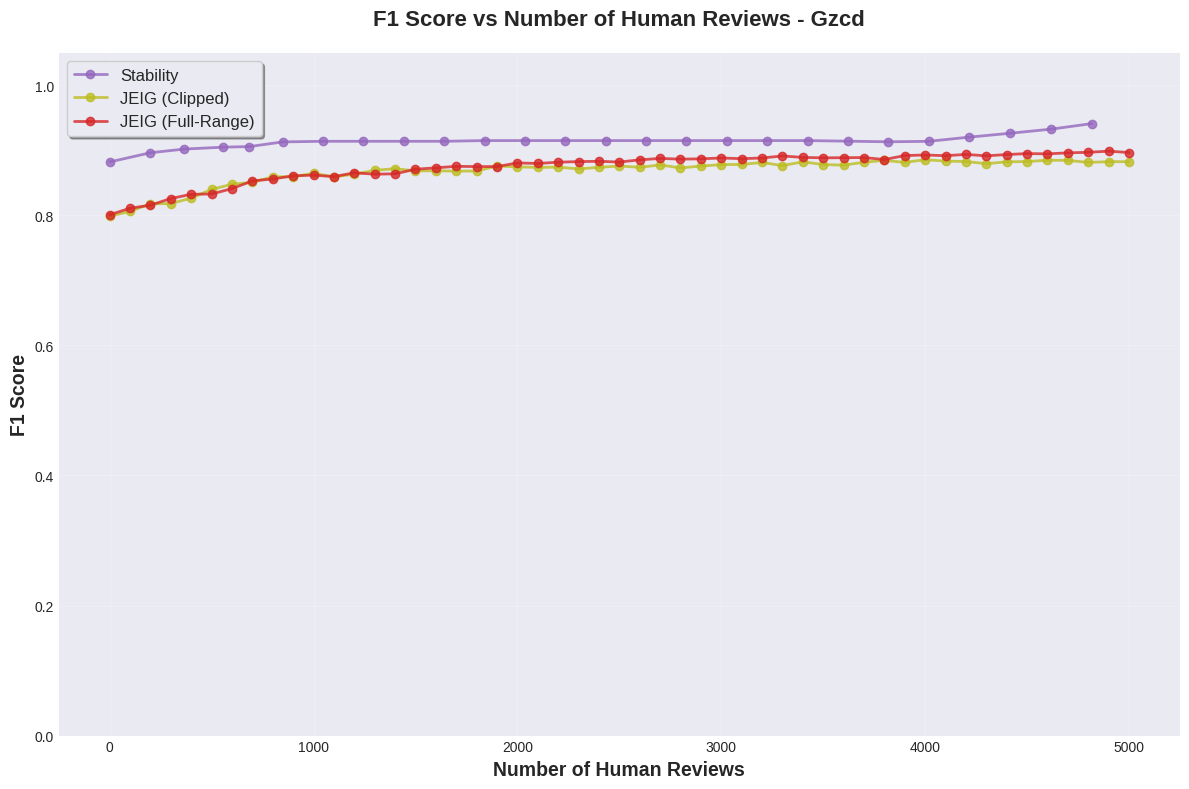

In [7]:
# Plot 1: F1 Score
fig1 = create_metric_plot('f1_score', 'F1 Score', f' - {SPECIES.capitalize()}')
plt.savefig(f'{PLOT_PATH}/{SPECIES}_f1_score_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## Precision vs Number of Human Reviews

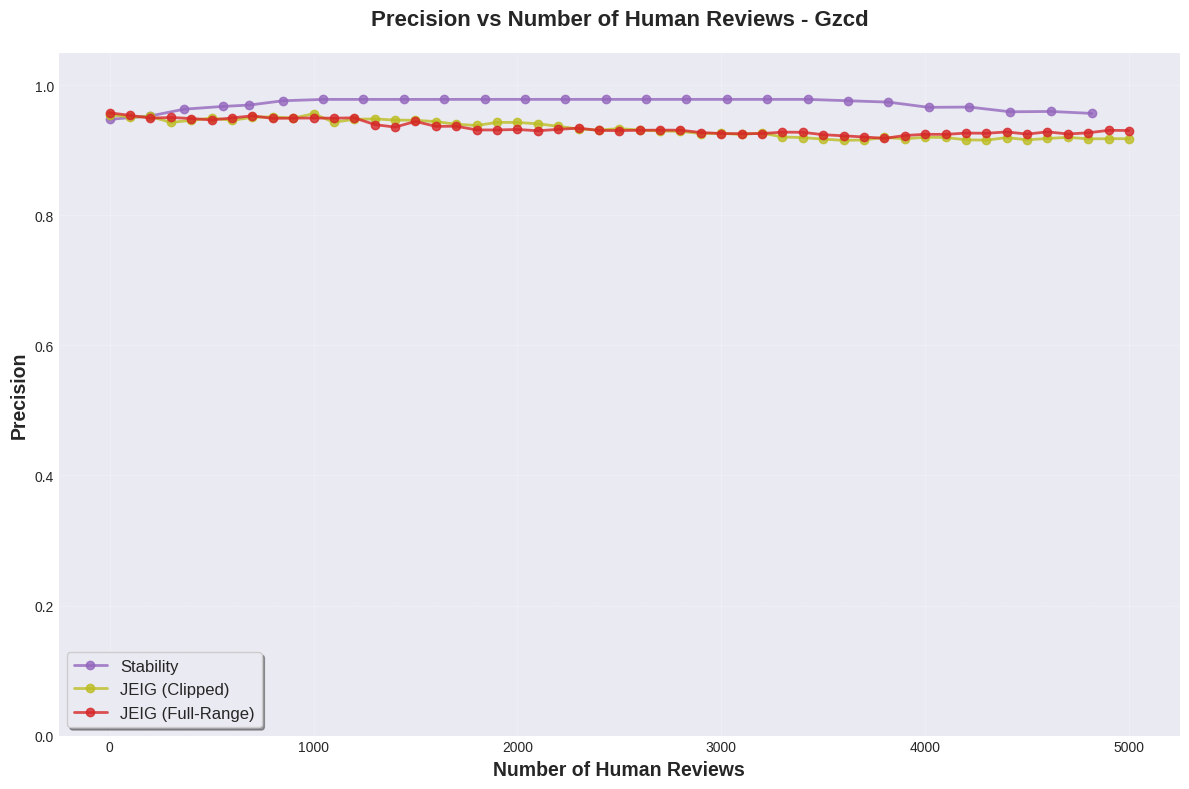

In [8]:
# Plot 2: Precision
fig2 = create_metric_plot('precision', 'Precision', f' - {SPECIES.capitalize()}')
plt.savefig(f'{PLOT_PATH}/{SPECIES}_precision_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## Recall vs Number of Human Reviews

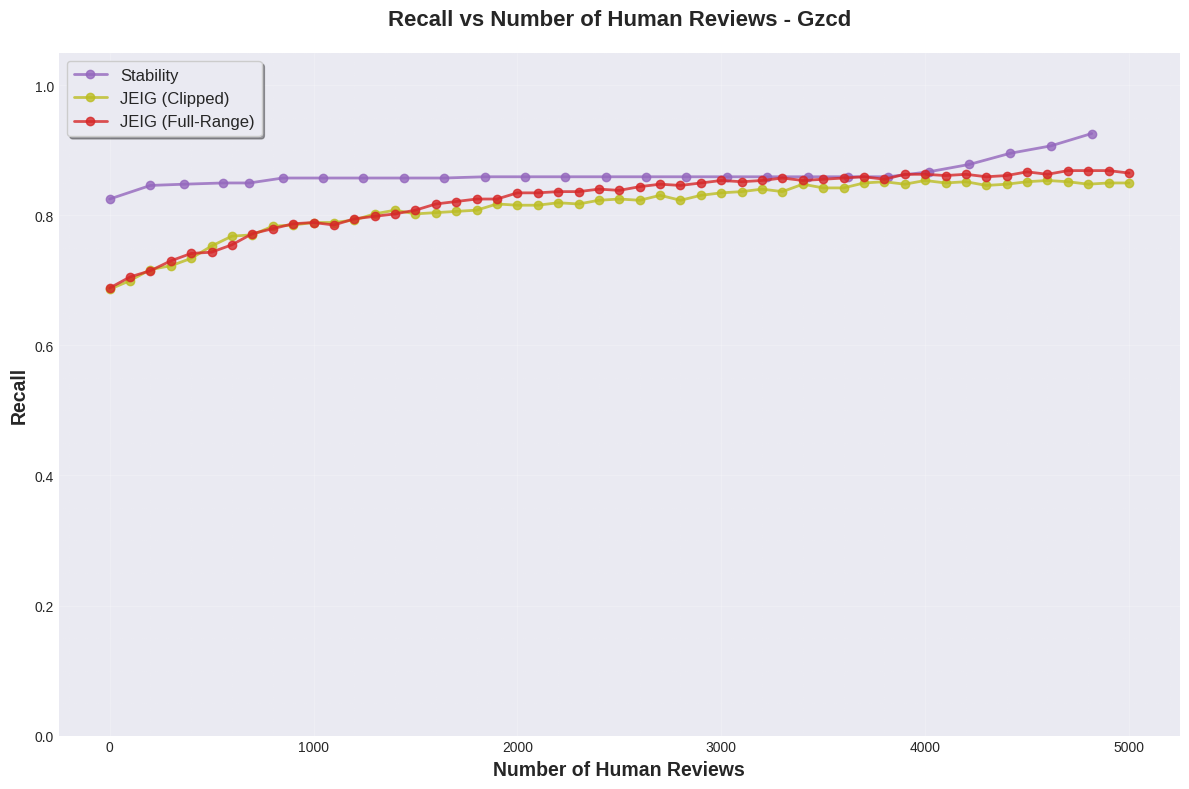

In [9]:
# Plot 3: Recall
fig3 = create_metric_plot('recall', 'Recall', f' - {SPECIES.capitalize()}')
plt.savefig(f'{PLOT_PATH}/{SPECIES}_recall_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## Fraction Correct vs Number of Human Reviews

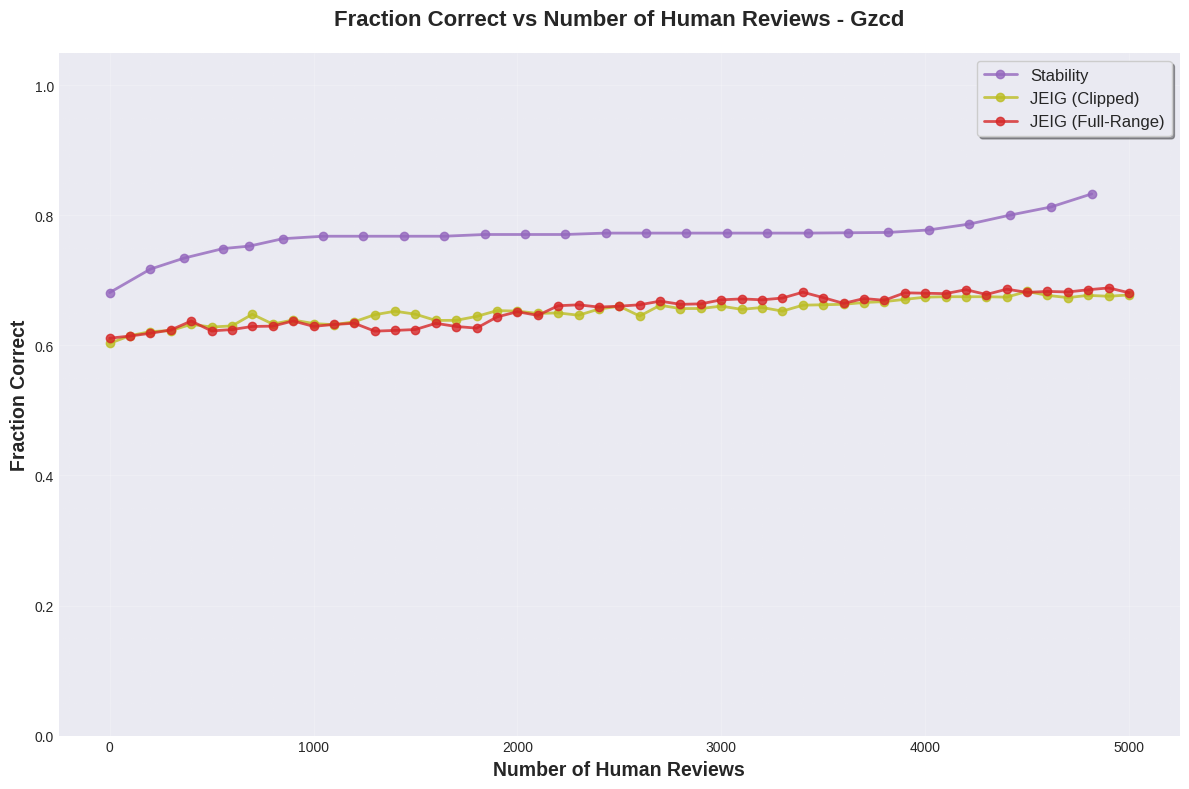

In [10]:
# Plot 4: Fraction Correct
fig4 = create_metric_plot('frac_correct', 'Fraction Correct', f' - {SPECIES.capitalize()}')
plt.savefig(f'{PLOT_PATH}/{SPECIES}_frac_correct_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## Combined Metrics Summary

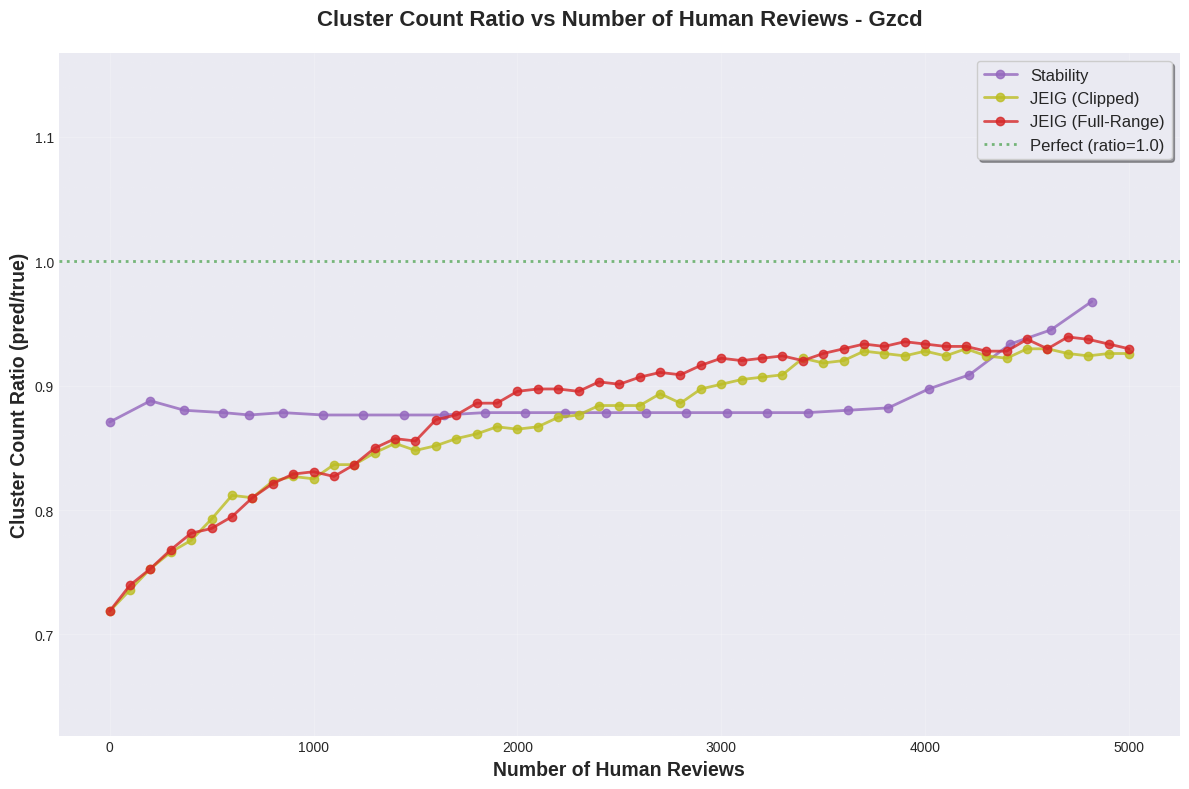


Cluster Count Summary:
Method               # Pred Clusters    # GT Clusters   Ratio     
----------------------------------------------------------------------
Stability            509                526             0.9677    
JEIG (Clipped)       487.0              526.0           0.9259    
JEIG (Full-Range)    489.0              526.0           0.9297    


In [11]:
# Plot 5: Cluster Count Ratio (predicted clusters / ground truth clusters)
# This metric shows how close the number of predicted clusters is to the true number
# Values close to 1.0 indicate the method found approximately the right number of clusters

def create_cluster_ratio_plot():
    """Create a plot for cluster count ratio across all methods"""
    fig, ax = plt.subplots(figsize=(12, 8))
    
    has_data = False
    for method, df in metrics_dfs.items():
        if df is not None and 'cluster_count_ratio' in df.columns:
            # Filter out None values
            valid_data = df.dropna(subset=['cluster_count_ratio'])
            if not valid_data.empty:
                has_data = True
                if method in HLINE_METHODS:
                    ax.axhline(y=valid_data['cluster_count_ratio'].iloc[0], 
                              color=METHOD_COLORS[method], 
                              linestyle='--', 
                              linewidth=2, 
                              label=f'{method} (no human review)',
                              alpha=0.8)
                else:
                    ax.plot(valid_data['num_human_reviews'], 
                           valid_data['cluster_count_ratio'], 
                           marker='o', 
                           markersize=6,
                           linewidth=2,
                           label=method, 
                           color=METHOD_COLORS[method],
                           alpha=0.8)
    
    if not has_data:
        ax.text(0.5, 0.5, 'No cluster count data available\nNeed to re-run algorithms to log cluster counts', 
               ha='center', va='center', transform=ax.transAxes, fontsize=14)
    
    # Add horizontal line at y=1.0 (perfect cluster count)
    ax.axhline(y=1.0, color='green', linestyle=':', linewidth=2, alpha=0.5, label='Perfect (ratio=1.0)')
    
    ax.set_xlabel('Number of Human Reviews', fontsize=14, fontweight='bold')
    ax.set_ylabel('Cluster Count Ratio (pred/true)', fontsize=14, fontweight='bold')
    ax.set_title(f'Cluster Count Ratio vs Number of Human Reviews - {SPECIES.capitalize()}', 
                fontsize=16, fontweight='bold', pad=20)
    
    ax.legend(loc='best', fontsize=12, frameon=True, shadow=True)
    ax.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)
    
    # Set y-axis limits - allow for over-clustering (ratio > 1) and under-clustering (ratio < 1)
    if has_data:
        all_ratios = []
        for method, df in metrics_dfs.items():
            if df is not None and 'cluster_count_ratio' in df.columns:
                valid = df['cluster_count_ratio'].dropna()
                if not valid.empty:
                    all_ratios.extend(valid.tolist())
        if all_ratios:
            min_ratio = min(all_ratios)
            max_ratio = max(all_ratios)
            ax.set_ylim([max(0, min_ratio - 0.1), max_ratio + 0.2])
    
    ax.minorticks_on()
    ax.grid(which='minor', alpha=0.1, linestyle=':', linewidth=0.5)
    
    plt.tight_layout()
    return fig

fig5 = create_cluster_ratio_plot()
plt.savefig(f'{PLOT_PATH}/{SPECIES}_cluster_count_ratio_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Print cluster count summary
print("\nCluster Count Summary:")
print("=" * 70)
print(f"{'Method':<20} {'# Pred Clusters':<18} {'# GT Clusters':<15} {'Ratio':<10}")
print("-" * 70)
for method, df in metrics_dfs.items():
    if df is not None and 'num_pred_clusters' in df.columns:
        # Get the last (most complete) data point
        last_row = df.iloc[-1]
        pred = last_row.get('num_pred_clusters', 'N/A')
        gt = last_row.get('num_gt_clusters', 'N/A')
        ratio = last_row.get('cluster_count_ratio', None)
        ratio_str = f"{ratio:.4f}" if ratio else "N/A"
        print(f"{method:<20} {str(pred):<18} {str(gt):<15} {ratio_str:<10}")

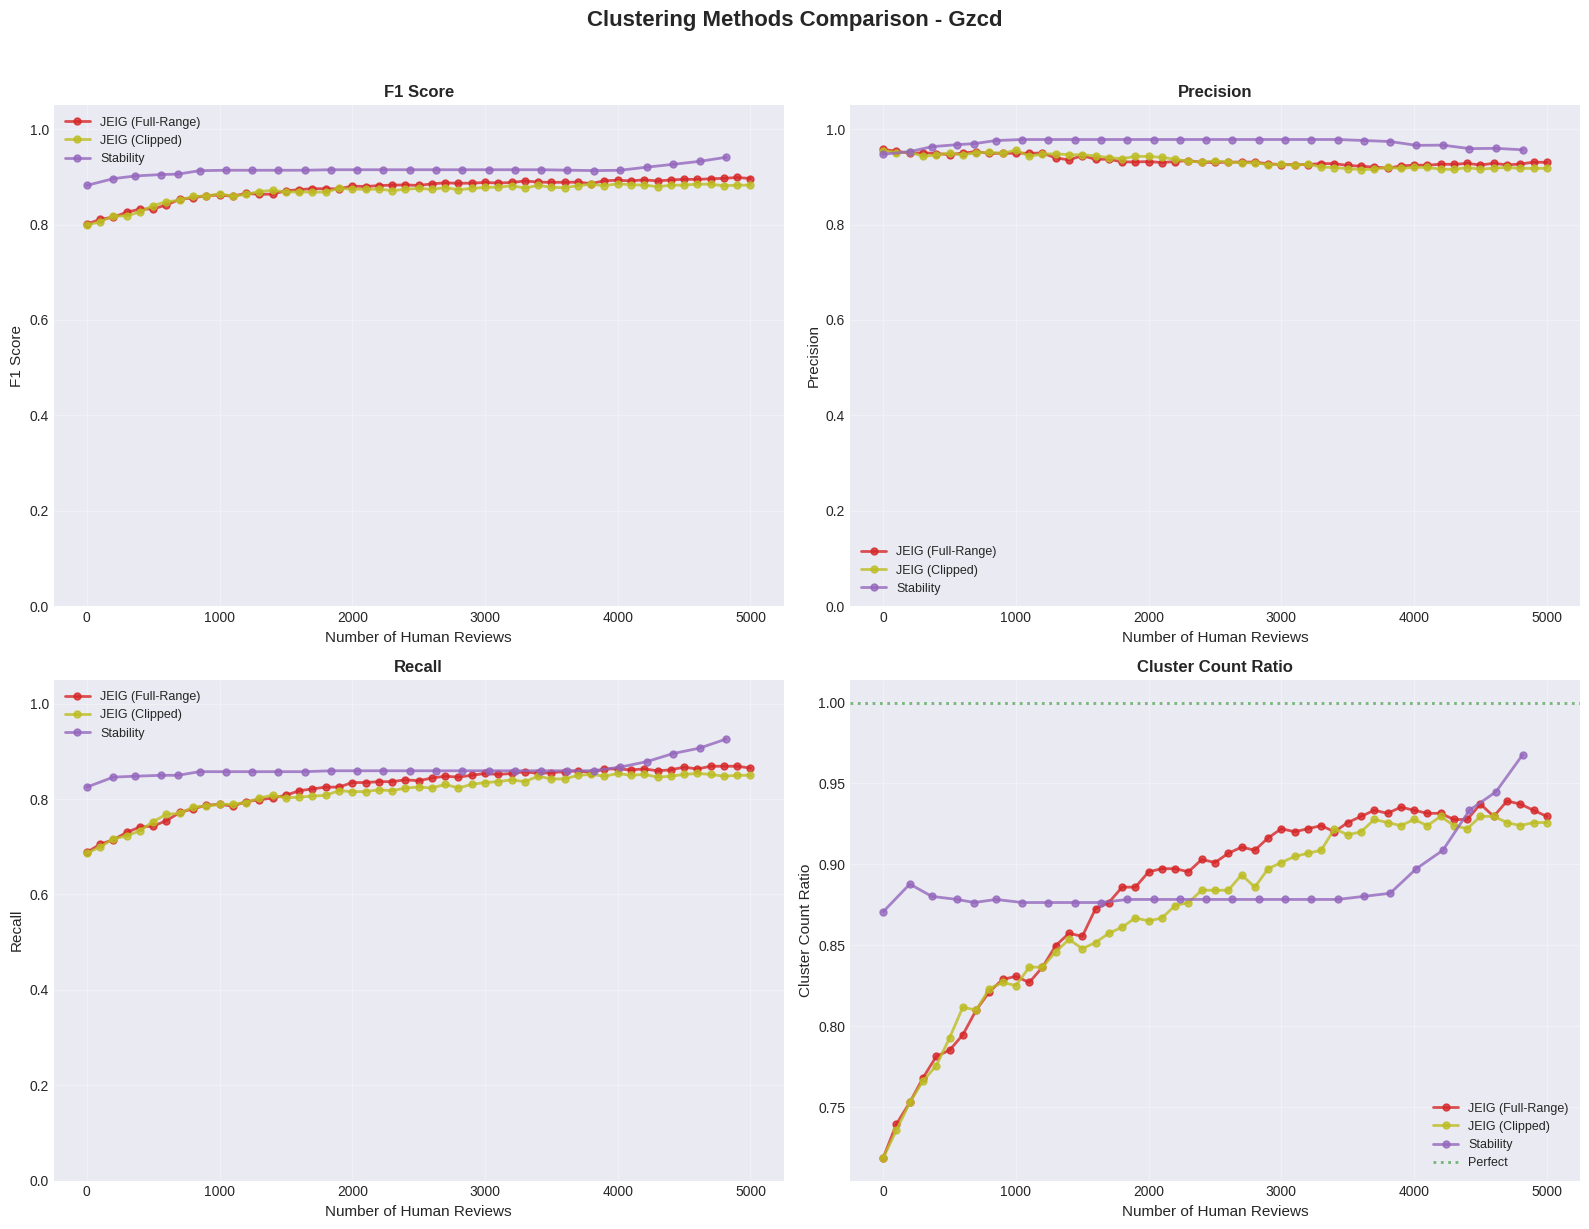

In [12]:
# Create a combined plot with all metrics (including cluster count ratio)
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
metrics = ['f1_score', 'precision', 'recall', 'cluster_count_ratio']
ylabels = ['F1 Score', 'Precision', 'Recall', 'Cluster Count Ratio']

for idx, (metric, ylabel) in enumerate(zip(metrics, ylabels)):
    ax = axes.flatten()[idx]
    
    for method, df in list(metrics_dfs.items())[::-1]:
        if df is not None and metric in df.columns:
            valid_data = df.dropna(subset=[metric]) if metric == 'cluster_count_ratio' else df
            if valid_data.empty:
                continue
                
            if method in HLINE_METHODS:
                ax.axhline(y=valid_data[metric].iloc[0], 
                          color=METHOD_COLORS[method], 
                          linestyle='--', 
                          linewidth=2, 
                          label=f'{method}',
                          alpha=0.8)
            else:
                ax.plot(valid_data['num_human_reviews'], 
                       valid_data[metric], 
                       marker='o', 
                       markersize=5,
                       linewidth=2,
                       label=method, 
                       color=METHOD_COLORS[method],
                       alpha=0.8)
    
    # Add reference line for cluster count ratio
    if metric == 'cluster_count_ratio':
        ax.axhline(y=1.0, color='green', linestyle=':', linewidth=2, alpha=0.5, label='Perfect')
    
    ax.set_xlabel('Number of Human Reviews', fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(ylabel, fontsize=12, fontweight='bold')
    ax.legend(loc='best', fontsize=9)
    ax.grid(True, alpha=0.3)
    
    # Set y-axis limits
    if metric != 'cluster_count_ratio':
        ax.set_ylim([0, 1.05])

fig.suptitle(f'Clustering Methods Comparison - {SPECIES.capitalize()}', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{PLOT_PATH}/{SPECIES}_all_metrics_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## Summary Statistics

In [13]:
# Export data to CSV for further analysis
for method, df in metrics_dfs.items():
    if df is not None:
        filename = f"{PLOT_PATH}/{SPECIES}_{method.lower().replace(' ', '_')}_metrics.csv"
        df.to_csv(filename, index=False)
        print(f"Exported {method} data to {filename}")

Exported Stability data to /fs/ess/PAS2136/ggr_data/results/aidan/GZCD/plots/GZCD_stability_metrics.csv
Exported JEIG (Clipped) data to /fs/ess/PAS2136/ggr_data/results/aidan/GZCD/plots/GZCD_jeig_(clipped)_metrics.csv
Exported JEIG (Full-Range) data to /fs/ess/PAS2136/ggr_data/results/aidan/GZCD/plots/GZCD_jeig_(full-range)_metrics.csv


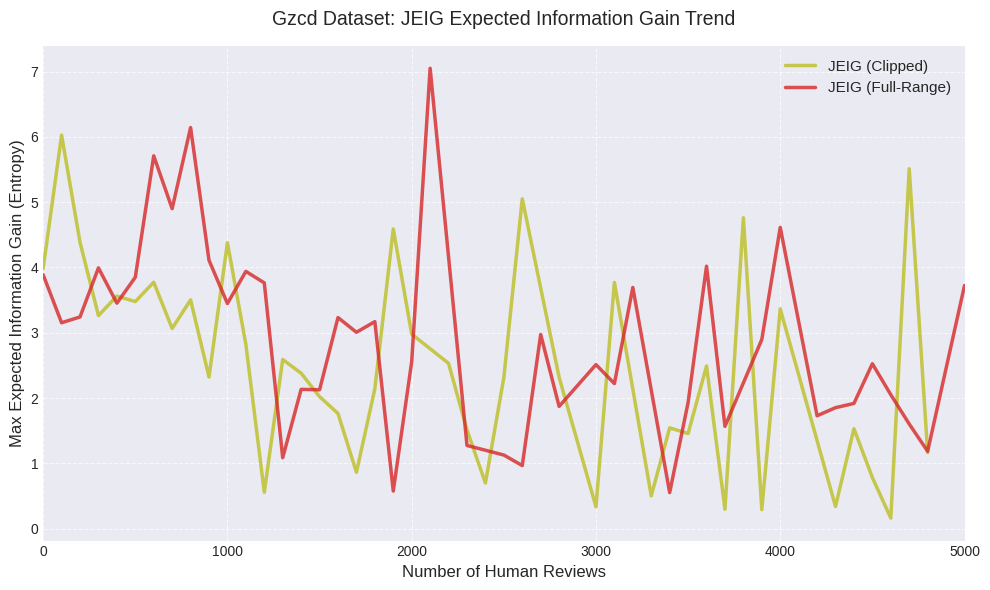

✓ Saved JEIG trend comparison plot to: /fs/ess/PAS2136/ggr_data/results/aidan/GZCD/plots/GZCD_jeig_trend_comparison.png


In [14]:
# ==========================================
# JEIG Trend Plot (Max Expected Information Gain vs Reviews)
# ==========================================
plt.figure(figsize=(10, 6))

# Find all methods that include 'JEIG' in their name
jeig_methods = [m for m in metrics_dfs.keys() if 'JEIG' in m]

has_jeig_data = False

for method in jeig_methods:
    df = metrics_dfs[method]
    
    # Filter only to rows that logged a max_jeig_score
    if 'max_jeig_score' in df.columns:
        plot_df = df.dropna(subset=['max_jeig_score'])
        
        if not plot_df.empty:
            has_jeig_data = True
            plt.plot(
                plot_df['num_human_reviews'], 
                plot_df['max_jeig_score'], 
                label=method, 
                color=METHOD_COLORS.get(method, '#000000'), 
                linewidth=2.5,
                alpha=0.8
            )

if has_jeig_data:
    plt.title(f'{SPECIES.capitalize()} Dataset: JEIG Expected Information Gain Trend', fontsize=14, pad=15)
    plt.xlabel('Number of Human Reviews', fontsize=12)
    plt.ylabel('Max Expected Information Gain (Entropy)', fontsize=12)
    
    # Set x-limit based on config
    max_x = min(max_human_reviews, max([metrics_dfs[m]['num_human_reviews'].max() for m in jeig_methods]))
    plt.xlim(left=0, right=max_x)
    
    # Add legend to distinguish Clipped vs Full-Range
    plt.legend(fontsize=11)
    
    # Add a subtle grid
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    
    # Save the plot
    jeig_plot_filename = PLOT_PATH / f'{SPECIES}_jeig_trend_comparison.png'
    plt.savefig(jeig_plot_filename, dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"✓ Saved JEIG trend comparison plot to: {jeig_plot_filename}")
else:
    print("No JEIG trend data found in the DataFrames. Make sure the log files contain 'JEIG_Trend' lines and the parsing cell ran correctly.")